# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/aijaz-khalique/flyrank-machine-learning-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

# Abstract

This project investigates how search performance signals can be used to prioritize content items for possible review or refresh.

Using an anonymized dataset of 30,000 content items, a binary classification approach was used to identify items associated with a declining historical trend. The target label was derived from the available `trend_direction` field, where `down` was treated as declining.

A Random Forest classifier was compared with a majority-class baseline using a fixed stratified 80/20 train-test split. Recall for the declining class was treated as the primary metric because missing a potentially declining item may reduce the usefulness of the review-prioritization process.

The model produces a decline probability for each test-set content item. These probabilities are used to create a ranked list of items that may deserve human review first.

The findings are directional and specific to the available dataset. The model does not establish causation, predict Google's algorithm, or guarantee that refreshing a page will improve performance. Its purpose is decision support for content review prioritization.

## 1. Question

*The research question and the decision it supports.*

Research Question

Which content items should be reviewed first for a possible content refresh?

The decision supported by this project is content prioritization. A content or SEO team may have many pages to review, so reviewing every page at the same time may not be practical.

This analysis helps identify content items that show a higher likelihood of declining performance. These items can then be prioritized for human review.

The final recommendation is not an automatic decision. A person should review the content before deciding whether to refresh, improve, protect, monitor, or take another action.

A wrong recommendation could waste time by sending attention to a page that does not need it. It could also miss a page that actually needs review.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*



The analysis uses the anonymized FlyRank ML Internship dataset.

The unit of analysis is one pseudonymized content item. Each row represents one content item and contains search, content, visibility, and engagement-related signals.

The dataset used in the earlier assignments contains 30,000 rows and 44 columns.

Examples of available information include:

- Content characteristics
- Search volume
- Competition information
- Content type
- Search intent
- Word and character counts
- Impressions
- Sessions
- Click-through rate
- Average position
- Engagement signals
- Scroll behavior

No real client names, domains, URLs, private search queries, or credentials are used in this public analysis.

The target column is `is_declining_label`.

- `1` means declining
- `0` means not declining

In [27]:
import pandas as pd
import numpy as np

df = pd.read_csv("../../data/raw/content_refresh_anonymized.csv")

print("Dataset shape:", df.shape)
print("\nFirst five rows:")
display(df.head())

print("\nColumn names:")
print(df.columns.tolist())

Dataset shape: (30000, 44)

First five rows:


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7



Column names:
['content_id', 'client_id', 'search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier', 'position_tier', 'trend_direction', 'trend_pct']


In [28]:
if "trend_direction" not in df.columns:
    raise ValueError("The dataset does not contain 'trend_direction'.")

df["is_declining_label"] = (
    df["trend_direction"]
    .astype(str)
    .str.lower()
    .eq("down")
    .astype(int)
)

target = "is_declining_label"

print("Selected target:", target)

print("\nTarget distribution:")
print(df[target].value_counts())

print("\nTarget percentages:")
print(
    (df[target].value_counts(normalize=True) * 100).round(2)
)

Selected target: is_declining_label

Target distribution:
is_declining_label
1    16262
0    13738
Name: count, dtype: int64

Target percentages:
is_declining_label
1    54.21
0    45.79
Name: proportion, dtype: float64


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*



### ML Task

This project is framed as a binary classification problem.

The goal is to identify whether a content item belongs to the declining class.

Target:

- `1` = Declining
- `0` = Not Declining

The main success metric is recall for the declining class.

Recall is important because the purpose of the project is to identify as many genuinely declining content items as possible. Missing a declining item could mean that an item needing review is not identified.

However, recall alone is not enough. Precision, F1 score, and accuracy are also reported because a very large number of false alerts would not be useful for a content team.

### Target Construction

The raw dataset did not contain a pre-existing `is_declining_label` column. The target was derived from `trend_direction`.

Items with a `down` trend were assigned `1`, while items with `stable` or `up` trends were assigned `0`.

The original trend fields are removed before model training because they directly define the target.

### Leakage Prevention

The following variables are excluded from model features:

- `is_declining_label`
- `trend_direction`
- `trend_pct`

Identifier columns are also excluded:

- `content_id`
- `client_id`

This prevents the model from directly seeing the target or information used to construct it.

### Validation Design

The data is split into:

- 80% training data
- 20% test data

A fixed random state of 42 is used for reproducibility.

Stratified splitting is used so that the proportion of declining and non-declining items is approximately maintained in both sets.

The preprocessing steps are fitted only on the training data through a scikit-learn pipeline.

Leakage Prevention

The target is based on declining trend information.

Therefore, variables that directly define or reveal the target must not be used as predictive features.

In particular, the following variables are excluded from the model features:

- `is_declining_label`
- `trend_direction`
- `trend_pct`

Identifier columns are also excluded from model features:

- `content_id`
- `client_id`

This is done to reduce target leakage and to make the evaluation more honest.

In [29]:

leakage_columns = [
    "is_declining_label",
    "trend_direction",
    "trend_pct"
]


id_columns = [
    "content_id",
    "client_id"
]

drop_columns = [
    col
    for col in leakage_columns + id_columns
    if col in df.columns
]


X = df.drop(columns=drop_columns)
y = df[target]

print("Target:", target)
print("Number of features:", X.shape[1])

print("\nColumns removed:")
print(drop_columns)

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget percentages:")
print(
    (y.value_counts(normalize=True) * 100).round(2)
)

Target: is_declining_label
Number of features: 40

Columns removed:
['is_declining_label', 'trend_direction', 'trend_pct', 'content_id', 'client_id']

Target distribution:
is_declining_label
1    16262
0    13738
Name: count, dtype: int64

Target percentages:
is_declining_label
1    54.21
0    45.79
Name: proportion, dtype: float64


In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTest target distribution:")
print(y_test.value_counts())

Training set: (24000, 40)
Test set: (6000, 40)

Training target distribution:
is_declining_label
1    13010
0    10990
Name: count, dtype: int64

Test target distribution:
is_declining_label
1    3252
0    2748
Name: count, dtype: int64


In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder


numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

print("\nNumeric columns:")
print(numeric_features)

print("\nCategorical columns:")
print(categorical_features)

Numeric features: 29
Categorical features: 11

Numeric columns:
['search_volume', 'competition', 'cpc', 'word_count', 'char_count', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier_order', 'days_since_last_update', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct']

Categorical columns:
['competition_level', 'content_type', 'main_intent', 'provider_used', 'model_used', 'age_tier', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'impression_tier', 'position_tier']


C:\Users\Dr.Shezad\AppData\Local\Temp\ipykernel_6488\2423261668.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


In [32]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*



Baseline

The baseline model always predicts the majority class.

This provides a simple reference point. The machine-learning model should provide more useful predictions than this baseline, especially for identifying the declining class.

In [33]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Baseline model
baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            DummyClassifier(
                strategy="most_frequent"
            )
        )
    ]
)

baseline_model.fit(X_train, y_train)

baseline_predictions = baseline_model.predict(X_test)

baseline_results = {
    "Model": "Majority Class Baseline",
    "Accuracy": accuracy_score(
        y_test,
        baseline_predictions
    ),
    "Precision": precision_score(
        y_test,
        baseline_predictions,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        baseline_predictions,
        zero_division=0
    ),
    "F1 Score": f1_score(
        y_test,
        baseline_predictions,
        zero_division=0
    )
}

baseline_results

{'Model': 'Majority Class Baseline',
 'Accuracy': 0.542,
 'Precision': 0.542,
 'Recall': 1.0,
 'F1 Score': 0.7029831387808041}

### Machine Learning Model

A Random Forest classifier is used as the main model.

Random Forest was selected because it can capture nonlinear relationships between content, search, and engagement signals without requiring strong assumptions about the shape of those relationships.

The model is evaluated on the same held-out test set as the baseline.

In [34]:
from sklearn.ensemble import RandomForestClassifier

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                class_weight="balanced",
                n_jobs=-1
            )
        )
    ]
)

# Train model
model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [35]:
model_predictions = model.predict(X_test)

model_probabilities = model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


In [36]:
model_results = {
    "Model": "Random Forest",
    "Accuracy": accuracy_score(
        y_test,
        model_predictions
    ),
    "Precision": precision_score(
        y_test,
        model_predictions,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        model_predictions,
        zero_division=0
    ),
    "F1 Score": f1_score(
        y_test,
        model_predictions,
        zero_division=0
    )
}

model_results

{'Model': 'Random Forest',
 'Accuracy': 0.8616666666666667,
 'Precision': 0.8627920910724985,
 'Recall': 0.8856088560885609,
 'F1 Score': 0.874051593323217}

In [37]:
results_df = pd.DataFrame(
    [
        baseline_results,
        model_results
    ]
)

results_df[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
].round(4)

,Model,Accuracy,Precision,Recall,F1 Score
0,Majority Class Baseline,0.5420,0.5420,1.0000,0.7030
1,Random Forest,0.8617,0.8628,0.8856,0.8741


### Results Interpretation

The baseline provides a reference point based on the majority class.

The Random Forest results show how much additional predictive signal is available from the content, search, visibility, and engagement features.

The main metric for this project is recall for the declining class. Precision and F1 score are also considered because a useful review-prioritization system should avoid producing an unnecessarily large number of false alerts.

These results are measured on the held-out test set and should be interpreted as directional evidence for this dataset rather than as a guarantee of performance on other websites.

In [38]:
print("Random Forest Classification Report:\n")

print(
    classification_report(
        y_test,
        model_predictions,
        target_names=[
            "Not Declining",
            "Declining"
        ],
        zero_division=0
    )
)

Random Forest Classification Report:

               precision    recall  f1-score   support

Not Declining       0.86      0.83      0.85      2748
    Declining       0.86      0.89      0.87      3252

     accuracy                           0.86      6000
    macro avg       0.86      0.86      0.86      6000
 weighted avg       0.86      0.86      0.86      6000



In [39]:
cm = confusion_matrix(
    y_test,
    model_predictions
)

cm_df = pd.DataFrame(
    cm,
    index=[
        "Actual Not Declining",
        "Actual Declining"
    ],
    columns=[
        "Predicted Not Declining",
        "Predicted Declining"
    ]
)

display(cm_df)

,Predicted Not Declining,Predicted Declining
Actual Not Declining,2290,458
Actual Declining,372,2880


## 5. Limitations

*What this work cannot claim.*

Limitations

This project has several limitations.

First, the analysis is based on an anonymized dataset. The results describe patterns observed in this dataset and may not generalize to every website or content environment.

Second, the target label is based on a defined rule related to trend information. It should not be treated as a perfect measure of the true business value of a content item.

Third, the model identifies associations in the available data. It does not prove that any individual feature causes a page to decline.

Fourth, the analysis does not predict Google's algorithm.

Finally, a high-priority recommendation does not mean that a page should automatically be changed. A human should review the content and surrounding context before taking action.

The results should therefore be understood as observed, directional, and decision-support evidence.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*



The trained model produces a probability score representing how strongly each test-set content item is associated with the declining class.

The items are ranked from highest to lowest decline probability.

This ranking is intended to help a content or SEO team decide which items may deserve review first.

The score is not a guarantee that a page will decline. It is a prioritization signal based on the model and the available data.

In [40]:
scored_df = X_test.copy()

scored_df["original_index"] = X_test.index

scored_df["actual_label"] = y_test.values

scored_df["decline_probability"] = model_probabilities


scored_df = scored_df.sort_values(
    by="decline_probability",
    ascending=False
)


scored_df["review_rank"] = range(
    1,
    len(scored_df) + 1
)

print("Top 10 content items by decline probability:")

display(
    scored_df[
        [
            "review_rank",
            "original_index",
            "decline_probability",
            "actual_label"
        ]
    ].head(10)
)

Top 10 content items by decline probability:


,review_rank,original_index,decline_probability,actual_label
8484,1,8484,0.995,1
15681,2,15681,0.995,1
2078,3,2078,0.995,1
12577,4,12577,0.995,1
15033,5,15033,0.995,1
22818,6,22818,0.990,1
10511,7,10511,0.990,1
2539,8,2539,0.990,1
13325,9,13325,0.990,1
2527,10,2527,0.990,1


In [41]:
def assign_priority(probability):
    if probability >= 0.75:
        return "High"
    elif probability >= 0.50:
        return "Medium"
    else:
        return "Lower"

scored_df["review_priority"] = (
    scored_df["decline_probability"]
    .apply(assign_priority)
)

display(
    scored_df[
        [
            "review_rank",
            "decline_probability",
            "review_priority",
            "actual_label"
        ]
    ].head(20)
)

,review_rank,decline_probability,review_priority,actual_label
8484,1,0.995,High,1
15681,2,0.995,High,1
2078,3,0.995,High,1
12577,4,0.995,High,1
15033,5,0.995,High,1
22818,6,0.990,High,1
10511,7,0.990,High,1
2539,8,0.990,High,1
13325,9,0.990,High,1
2527,10,0.990,High,1


### Recommendation Playbook

- **High priority:** Review first because the model assigns a relatively high declining probability.
- **Medium priority:** Review after the highest-priority items or when additional capacity is available.
- **Lower priority:** Monitor or review later unless other business information suggests higher importance.

These categories are operational guidelines rather than guaranteed outcomes.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

In [42]:
results_table = results_df[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
].copy()

results_table[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
] = results_table[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
].round(3)

display(results_table)

,Model,Accuracy,Precision,Recall,F1 Score
0,Majority Class Baseline,0.542,0.542,1.000,0.703
1,Random Forest,0.862,0.863,0.886,0.874


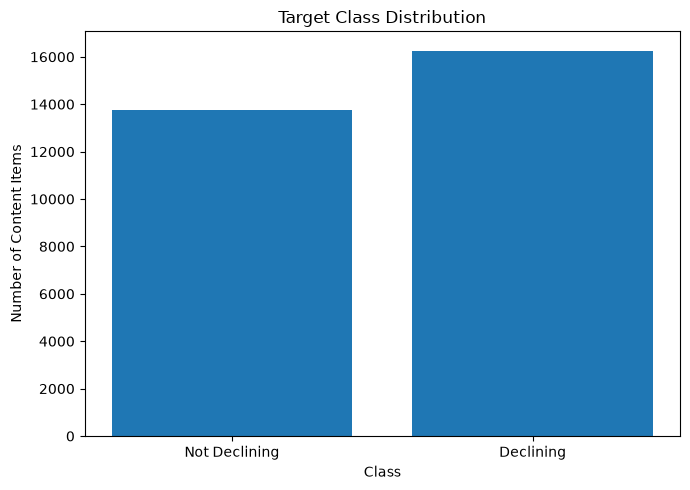

In [43]:
import matplotlib.pyplot as plt

target_counts = y.value_counts().sort_index()

labels = [
    "Not Declining",
    "Declining"
]

plt.figure(figsize=(7, 5))

plt.bar(
    labels,
    [
        target_counts.get(0, 0),
        target_counts.get(1, 0)
    ]
)

plt.title("Target Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Content Items")

plt.tight_layout()
plt.show()

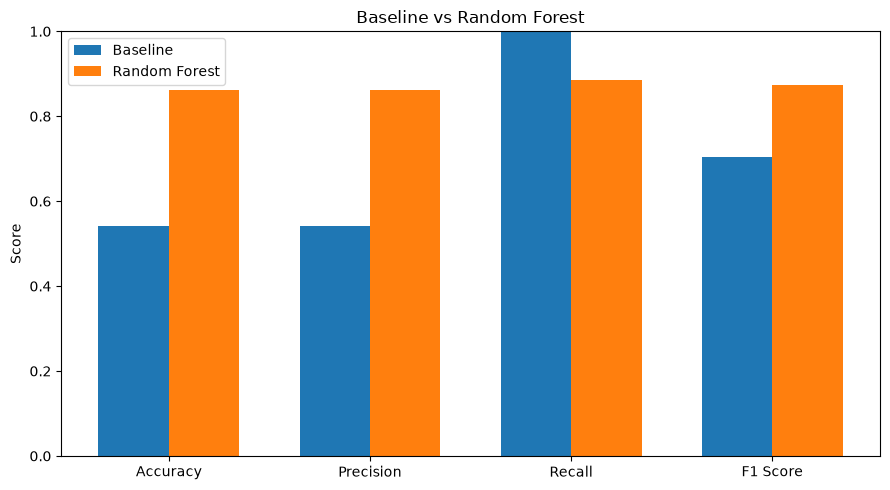

In [44]:
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]

x = np.arange(len(metrics))
width = 0.35

baseline_values = [
    baseline_results[m]
    for m in metrics
]

model_values = [
    model_results[m]
    for m in metrics
]

plt.figure(figsize=(9, 5))

plt.bar(
    x - width / 2,
    baseline_values,
    width,
    label="Baseline"
)

plt.bar(
    x + width / 2,
    model_values,
    width,
    label="Random Forest"
)

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.ylim(0, 1)
plt.title("Baseline vs Random Forest")
plt.legend()

plt.tight_layout()
plt.show()

In [45]:
top_recommendations = scored_df[
    [
        "review_rank",
        "decline_probability",
        "review_priority",
        "actual_label"
    ]
].head(20).copy()

top_recommendations["decline_probability"] = (
    top_recommendations["decline_probability"]
    .round(3)
)

display(top_recommendations)

,review_rank,decline_probability,review_priority,actual_label
8484,1,0.995,High,1
15681,2,0.995,High,1
2078,3,0.995,High,1
12577,4,0.995,High,1
15033,5,0.995,High,1
22818,6,0.990,High,1
10511,7,0.990,High,1
2539,8,0.990,High,1
13325,9,0.990,High,1
2527,10,0.990,High,1


In [46]:
print("========== FINAL CAPSTONE RESULTS ==========")

print("\nDataset:")
print("Rows:", len(df))
print("Original columns:", 44)

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget percentages:")
print((y.value_counts(normalize=True) * 100).round(2))

print("\nModel comparison:")
display(results_table)

print("\nClassification report:")
print(
    classification_report(
        y_test,
        model_predictions,
        target_names=["Not Declining", "Declining"],
        zero_division=0
    )
)

print("\nTop 10 recommendations:")
display(
    top_recommendations.head(10)
)

========== FINAL CAPSTONE RESULTS ==========

Dataset:
Rows: 30000
Original columns: 44

Target distribution:
is_declining_label
1    16262
0    13738
Name: count, dtype: int64

Target percentages:
is_declining_label
1    54.21
0    45.79
Name: proportion, dtype: float64

Model comparison:


,Model,Accuracy,Precision,Recall,F1 Score
0,Majority Class Baseline,0.542,0.542,1.000,0.703
1,Random Forest,0.862,0.863,0.886,0.874



Classification report:
               precision    recall  f1-score   support

Not Declining       0.86      0.83      0.85      2748
    Declining       0.86      0.89      0.87      3252

     accuracy                           0.86      6000
    macro avg       0.86      0.86      0.86      6000
 weighted avg       0.86      0.86      0.86      6000


Top 10 recommendations:


,review_rank,decline_probability,review_priority,actual_label
8484,1,0.995,High,1
15681,2,0.995,High,1
2078,3,0.995,High,1
12577,4,0.995,High,1
15033,5,0.995,High,1
22818,6,0.990,High,1
10511,7,0.990,High,1
2539,8,0.990,High,1
13325,9,0.990,High,1
2527,10,0.990,High,1


# Acknowledgments & Data Credit

This project was completed as part of the FlyRank ML Internship capstone.

The analysis uses the anonymized FlyRank internship dataset provided for educational and research purposes.

Data and project context credit:

https://flyrank.ai

The analysis is intended for educational and decision-support purposes. It does not use or expose private client information, credentials, URLs, or confidential search queries.

# ML-12 — 5-Minute Demo Outline

## 1. Problem — 45 seconds

Explain that content teams may have many pages and need a way to prioritize which pages deserve review first.

## 2. Data — 45 seconds

Explain that the project uses 30,000 anonymized content items with search, content, visibility, and engagement signals.

## 3. Method — 1 minute

Explain that the project creates a declining label from `trend_direction`, removes leakage variables, preprocesses numeric and categorical features, and trains a Random Forest classifier.

## 4. Results — 1 minute

Show the baseline versus Random Forest metrics, focusing mainly on recall for the declining class while also considering precision and F1 score.

## 5. Recommendations — 45 seconds

Show the ranked content items and explain that higher decline probability means the item may deserve earlier human review.

## 6. Limitations — 45 seconds

Explain that the model provides directional decision support. It does not prove causation, predict Google's algorithm, or guarantee that refreshing content will improve performance.

# ML-12 — Social Post Cut

I built a machine-learning capstone to help prioritize content items for possible review or refresh.

Using 30,000 anonymized content items and search-performance signals, I created a declining-content classification task and trained a Random Forest model to rank items by their estimated decline probability.

The goal is not to predict Google's algorithm or automate content decisions. Instead, the model provides a decision-support signal that can help a content team decide where human review may be most useful.

Key lessons from the project included leakage prevention, imbalanced classification, model evaluation, and turning model probabilities into practical recommendations.

#MachineLearning #DataScience #SEO #ContentStrategy #Python

# ML-12 — Employer-Facing Summary

I developed a machine-learning decision-support system that ranks anonymized content items by their likelihood of belonging to a declining-performance group. I handled target construction, leakage prevention, mixed-type feature preprocessing, model training, baseline comparison, evaluation, and ranked recommendations using Python and scikit-learn. The resulting workflow demonstrates how machine-learning predictions can be translated into practical prioritization signals while keeping conclusions appropriately cautious and data-driven.

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [x] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [x] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
